# Data Science Lab on Smart Cities

## Decoding the Intersection between Ridesourcing Dependency and Socio-Health Vulnerability in the Chicago FUA

Research question: Is ridesourcing acting as a mobility equalizer or as a costly substitute for inadequate public transport in vulnerable peripheral areas of Chicago?

Analysis:
1. DATA 
2. CONSTRUCT INDICATORS: 
   - TNP Usage Intensity (TUI), 
   - Public Transport Accessibility (PTA), and 
   - Health Vulnerability Index (HVI) 
3. ...

### 1. Data Sources: 

- CMAP Community Data Snapshots - https://services5.arcgis.com/LcMXE3TFhi1BSaCY/arcgis/rest/services/CommunityDataSnapshots_2015_2025_gdb/FeatureServer
DATA HUB link: https://datahub.cmap.illinois.gov/search?tags=community%2520data%2520snapshots

- Transportation Network Providers - Trips(Chicago Data Portal)
        - 2018 - 2022: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2018-2022-/m6dm-c72p/data_preview
        - 2023 - 2024: https://data.cityofchicago.org/Transportation/Transportation-Network-Providers-Trips-2023-2024-/n26f-ihde/data_preview

- Boundaries - Community Areas (Chicago Data Portal)
https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6


### TNP USAGE INTENSITY (TUI)
TNP Usage Intensity measures the number of ridesourcing trips generated in a Community Area during a given time period, normalized by the resident population. Higher values indicate more TNP activity per resident. 
The index should be interpreted as usage intensity rather than dependency unless combined with indicators of public transport accessibility. 

$$TUI= \frac{TNP pickups_{i,m}}{population_{i,m}} *1000$$

where:
- i: community area
- m: month
- TNP pickups: number of ridesourcing trips startint in that community area
- Population: resident population in the community area


In [1]:
#imports
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from utils import source_tnp_counts, load_all_cca_population, plot_tui_index


In [2]:
#TNP Usage Data - source via API  
url_2023_2024 = "https://data.cityofchicago.org/resource/n26f-ihde.json"
source_tnp_counts(url_2023_2024, "tnp_counts_2023-2024")

In [3]:
url_2018_2022 = "https://data.cityofchicago.org/resource/m6dm-c72p.json"
source_tnp_counts(url_2018_2022, "tnp_counts_2018-2022")

In [12]:
#aggregate tnp counts with population size
tnp_counts_2018_2022 = pd.read_csv("data/tnp_counts_2018-2022.csv")
tnp_counts_2023_2024 = pd.read_csv("data/tnp_counts_2023-2024.csv")
tnp_counts = pd.concat([tnp_counts_2018_2022, tnp_counts_2023_2024], ignore_index=True)
tnp_counts["month"] = pd.to_datetime(tnp_counts["month"])
tnp_counts["year"] = tnp_counts["month"].dt.year
tnp_counts = tnp_counts.rename(columns={"pickup_community_area": "community_area"})

population = load_all_cca_population("data")

df = pd.merge(tnp_counts, population, on=["community_area", "year"], how="left")

In [16]:
#Calulcate TUI Index
df["tui_index"] = (df["n_trips"] / df["population"])*1000

In [18]:
df.to_csv("data/tui_index.csv", index=False)
df.head()

,month,community_area,n_trips,year,community_area_name,population,tui_index
0,2018-11-01,1,99221,2018,Rogers Park,55500.0,1787.765766
1,2018-11-01,2,71955,2018,West Ridge,73723.0,976.018339
2,2018-11-01,3,187550,2018,Uptown,56296.0,3331.497797
3,2018-11-01,4,89958,2018,Lincoln Square,41483.0,2168.550973
4,2018-11-01,5,104623,2018,North Center,34942.0,2994.190373


In [2]:
#plot tui index by community area
tui = pd.read_csv("data/tui_index.csv", parse_dates=["month"])

chicago_community_areas = gpd.read_file("data/Boundaries_-_Community_Areas_20260607.geojson")
chicago_community_areas = chicago_community_areas.rename(columns={
    "area_num_1": "community_area",
    "community": "community_area_name"
})

chicago_community_areas["community_area"] = chicago_community_areas["community_area"].astype(int)

tui_2018 = (
    tui[tui["year"] == 2018]
    .groupby("community_area", as_index=False)["tui_index"]
    .median()
)

tui_2024 = (
    tui[tui["year"] == 2024]
    .groupby("community_area", as_index=False)["tui_index"]
    .median()
)

tui_map_2018 = chicago_community_areas.merge(tui_2018, on="community_area", how="left")
tui_map_2024 = chicago_community_areas.merge(tui_2024, on="community_area", how="left")

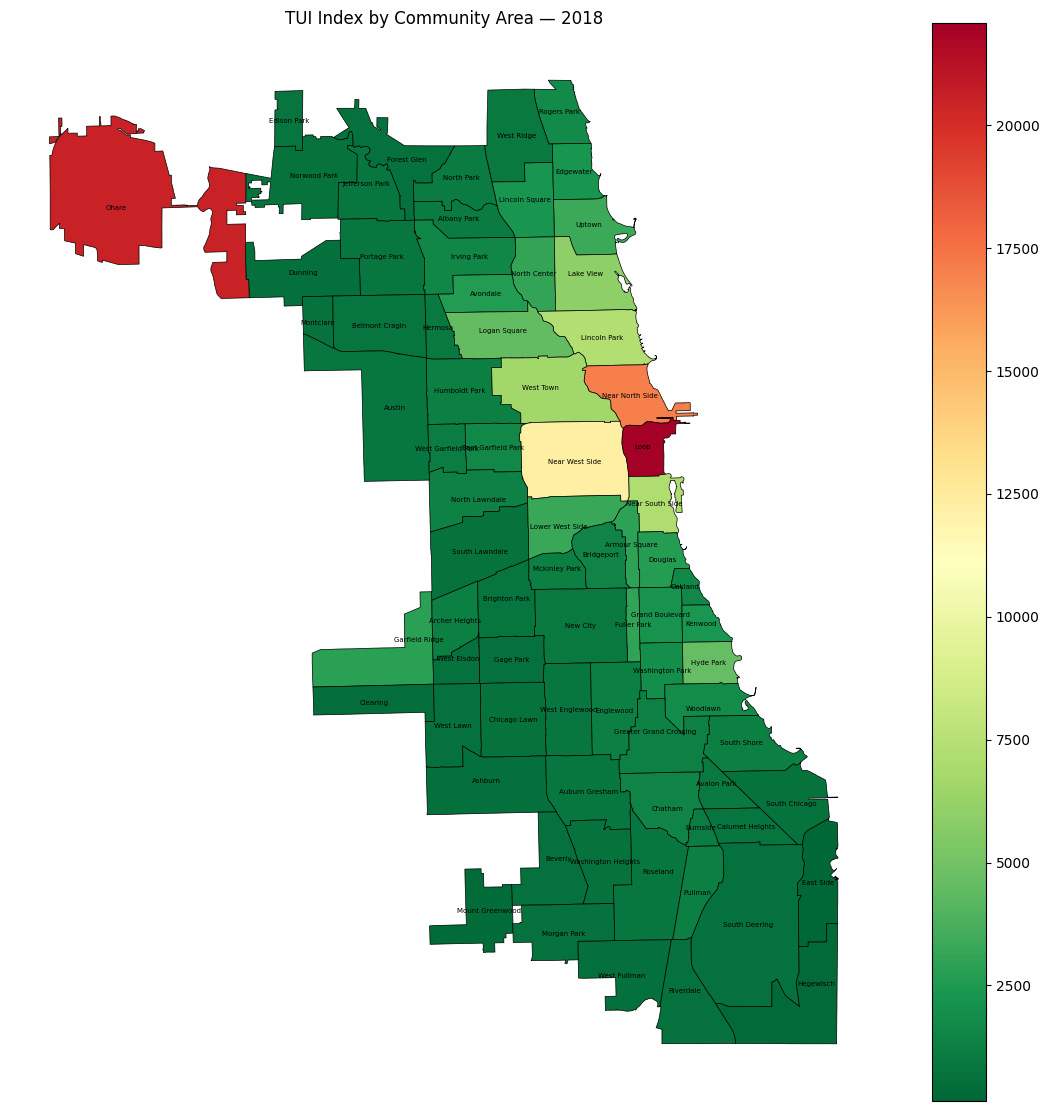

In [3]:
plot_tui_index(tui_map_2018, "2018")

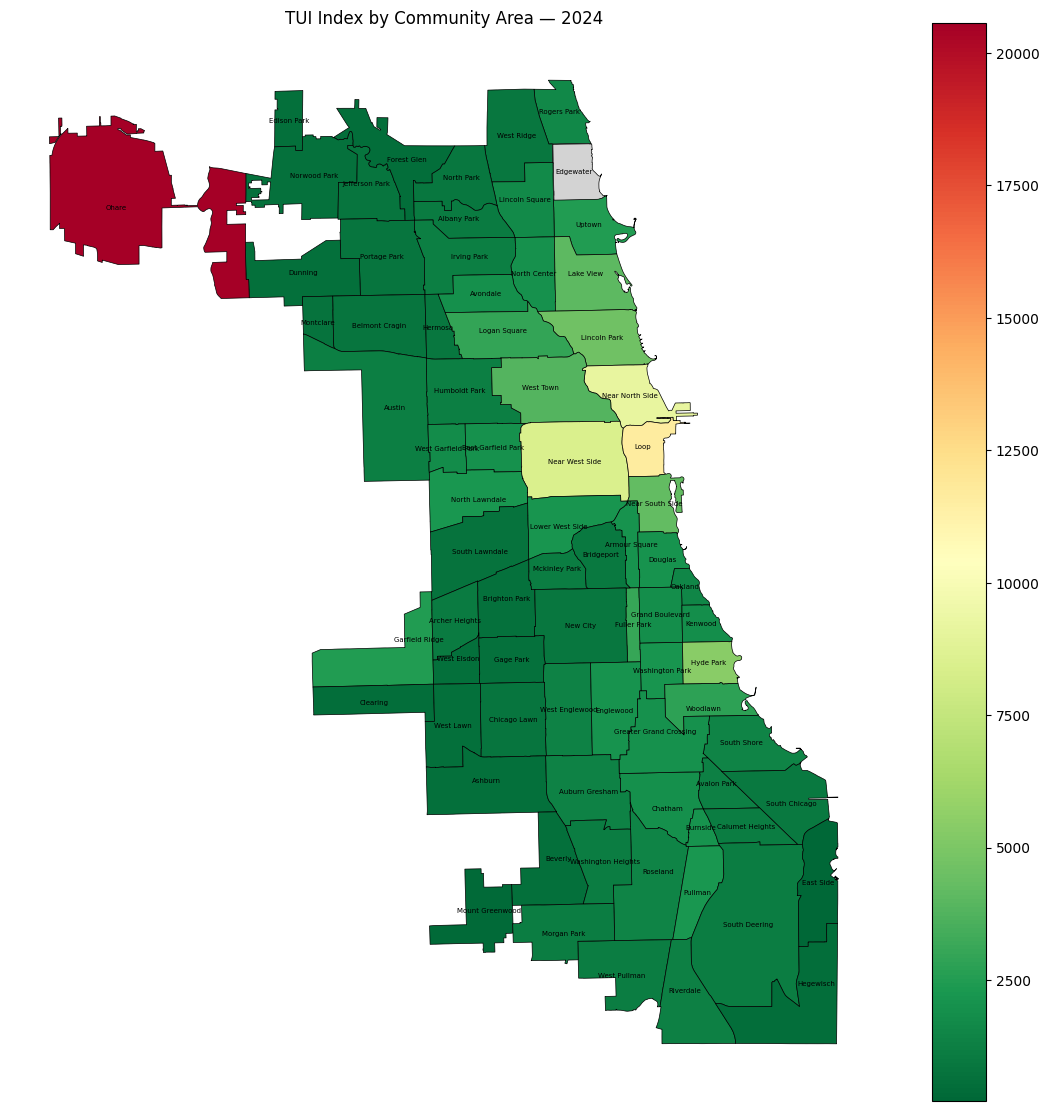

In [4]:
plot_tui_index(tui_map_2024, "2024")